In [4]:
from sklearn.datasets import load_breast_cancer, load_diabetes
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from PNN import TrainablePNN, PNN
from GRNN import GRNN, TrainableGRNN
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import torch

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [9]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9
1.0


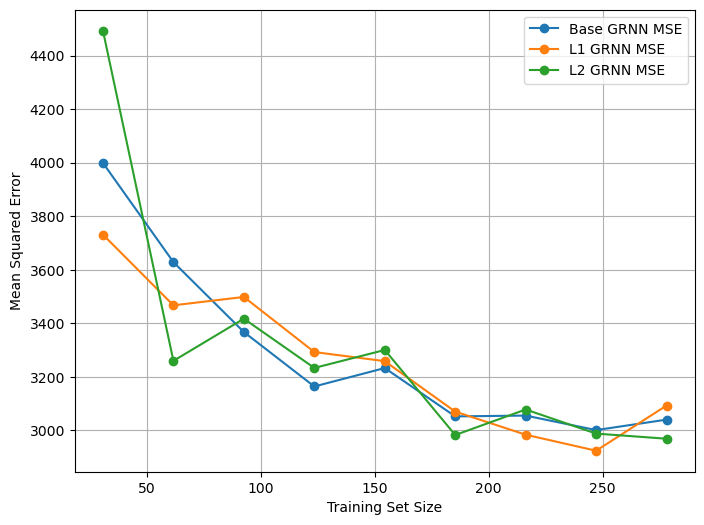

In [10]:
data = load_diabetes()

X = data['data']
y = data['target'].reshape(-1, 1)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

train_sizes = np.linspace(0.1, 1.0, 10)
test_errors = []
test_errors_l1 = []
test_errors_l2 = []

for train_size in train_sizes:
    print(train_size)

    if train_size == 1.0:
        continue
 
    X_train_part, _, y_train_part, _ = train_test_split(X_train_full, y_train_full, train_size=train_size, random_state=42)

    set_seed()
    
    grnn = GRNN(sigma=1.0, kernel='gaussian')
    grnn_l1 = TrainableGRNN(sigma=1.0, regularization='l1', tau=2.9)
    grnn_l2 = TrainableGRNN(sigma=1.0, regularization='l2', tau=4.4)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_part)
    y_train_scaled = y_scaler.fit_transform(y_train_part)

    X_test_scaled = x_scaler.transform(X_test)
    y_test_scaled = y_scaler.transform(y_test)
    
    grnn.fit(X_train_scaled, y_train_scaled.ravel())
    grnn_l1.fit(X_train_scaled, y_train_scaled.ravel())
    grnn_l2.fit(X_train_scaled, y_train_scaled.ravel())

    y_test_pred = [grnn.predict(x) for x in X_test_scaled]
    y_test_pred_l1 = [grnn_l1.predict(x) for x in X_test_scaled]
    y_test_pred_l2 = [grnn_l2.predict(x) for x in X_test_scaled]

    y_test_pred = y_scaler.inverse_transform(np.array(y_test_pred).reshape(-1, 1)).ravel()
    y_test_pred_l1 = y_scaler.inverse_transform(np.array(y_test_pred_l1).reshape(-1, 1)).ravel()
    y_test_pred_l2 = y_scaler.inverse_transform(np.array(y_test_pred_l2).reshape(-1, 1)).ravel()

    test_errors.append(mean_squared_error(y_test, y_test_pred))
    test_errors_l1.append(mean_squared_error(y_test, y_test_pred_l1))
    test_errors_l2.append(mean_squared_error(y_test, y_test_pred_l2))

plt.figure(figsize=(8,6))
plt.plot(train_sizes[:-1] * len(X_train_full), test_errors, label='Base GRNN MSE', marker='o')
plt.plot(train_sizes[:-1] * len(X_train_full), test_errors_l1, label='L1 GRNN MSE', marker='o')
plt.plot(train_sizes[:-1] * len(X_train_full), test_errors_l2, label='L2 GRNN MSE', marker='o')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.savefig('./visualization/grnn_learning_curve.png')
plt.show()

0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9
1.0


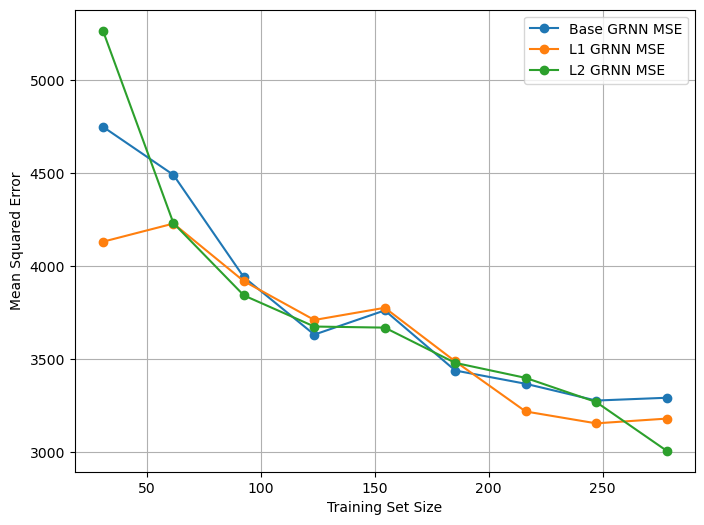

In [15]:
df = pd.read_excel('data/Concrete_Data.xls')

X_train = df.iloc[:, :-1].values
y_train = df.iloc[:, -1].values.reshape(-1, 1)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

train_sizes = np.linspace(0.1, 1.0, 10)
test_errors = []
test_errors_l1 = []
test_errors_l2 = []

for train_size in train_sizes:
    print(train_size)

    if train_size == 1.0:
        continue
 
    X_train_part, _, y_train_part, _ = train_test_split(X_train_full, y_train_full, train_size=train_size, random_state=42)

    set_seed()
    
    grnn = GRNN(sigma=0.7, kernel='gaussian')
    grnn_l1 = TrainableGRNN(sigma=0.7, regularization='l1', tau=2.3)
    grnn_l2 = TrainableGRNN(sigma=0.7, regularization='l2', tau=3.3)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train_part)
    y_train_scaled = y_scaler.fit_transform(y_train_part)

    X_test_scaled = x_scaler.transform(X_test)
    y_test_scaled = y_scaler.transform(y_test)
    
    grnn.fit(X_train_scaled, y_train_scaled.ravel())
    grnn_l1.fit(X_train_scaled, y_train_scaled.ravel())
    grnn_l2.fit(X_train_scaled, y_train_scaled.ravel())

    y_test_pred = [grnn.predict(x) for x in X_test_scaled]
    y_test_pred_l1 = [grnn_l1.predict(x) for x in X_test_scaled]
    y_test_pred_l2 = [grnn_l2.predict(x) for x in X_test_scaled]

    y_test_pred = y_scaler.inverse_transform(np.array(y_test_pred).reshape(-1, 1)).ravel()
    y_test_pred_l1 = y_scaler.inverse_transform(np.array(y_test_pred_l1).reshape(-1, 1)).ravel()
    y_test_pred_l2 = y_scaler.inverse_transform(np.array(y_test_pred_l2).reshape(-1, 1)).ravel()

    test_errors.append(mean_squared_error(y_test, y_test_pred))
    test_errors_l1.append(mean_squared_error(y_test, y_test_pred_l1))
    test_errors_l2.append(mean_squared_error(y_test, y_test_pred_l2))

plt.figure(figsize=(8,6))
plt.plot(train_sizes[:-1] * len(X_train_full), test_errors, label='Base GRNN MSE', marker='o')
plt.plot(train_sizes[:-1] * len(X_train_full), test_errors_l1, label='L1 GRNN MSE', marker='o')
plt.plot(train_sizes[:-1] * len(X_train_full), test_errors_l2, label='L2 GRNN MSE', marker='o')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.savefig('./visualization/grnn_learning_curve_concrete.png')
plt.show()